In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean 
import cftime
import gsw

### load time mean global Temerpature (T) and Salinity (S) (function of latitude, longitude, and depth)

In [2]:
woa18_data = xr.open_zarr('C:/Users/TU_Climate24_Student/Desktop/Phys_Oc/physical_oceanography/data/woa18_full_decadal_ave_fields')

# ocean depth
etopo5_data = xr.open_dataset('http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NGDC/.ETOPO5/dods')
etopo5_data = etopo5_data.rename({'X': 'lon', 'Y': 'lat'})
etopo5_data['elev_ocean'] = etopo5_data.elev.where(etopo5_data.elev<0).load()
etopo5_data

<xarray.Dataset>
Dimensions:     (lat: 2160, lon: 4320)
Coordinates:
  * lat         (lat) float32 90.0 89.92 89.83 89.75 ... -89.75 -89.83 -89.92
  * lon         (lon) float32 0.0 0.08333 0.1667 0.25 ... 359.8 359.8 359.9
Data variables:
    elev        (lat, lon) int16 -4290 -4290 -4290 -4290 ... 2774 2774 2774 2774
    elev_ocean  (lat, lon) float32 -4.29e+03 -4.29e+03 -4.29e+03 ... nan nan nan
Attributes:
    dataset_documentation.html:  http://iridl.ldeo.columbia.edu/SOURCES/.NOAA...
    Conventions:                 IRIDL
    description:                 ETOPO5 5x5 minute land surface elevations an...

In [3]:
woa18_data

<xarray.Dataset>
Dimensions:   (depth: 102, lat: 180, lon: 360)
Coordinates:
  * depth     (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat       (lat) float32 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float32 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    nitrate   (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>
    oxygen    (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>
    salinity  (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>
    temp      (depth, lat, lon) float32 dask.array<chunksize=(26, 45, 180), meta=np.ndarray>

In [4]:
# key fields we'll be working with
temp = woa18_data.temp
salt = woa18_data.salinity
depth = woa18_data.depth
elev = etopo5_data.elev
elev_ocean = etopo5_data.elev_ocean

## In this exercise, we are going to use global fields of T and S to:

- compute potential density
- estimate horizontal density gradients
- leverage the thermal wind relation to estimate geostrophic velocities associated with density gradients

We'll walk through a procedure step by step and generate some figures to get a sense of the distributions of temperature, salinity, and density throughout the ocean

### todo: Using the gibbs seawater package (gsw), compute at all latitudes, longitudes, and depths potential density referenced to the surface (sigma0). 

This will first require calculations of absolute salinity and conservative temperature. Remember sigma references some density - 1000 kg/m^3. The units needed to be in decibar for GSW so I converted to decibar and got 0.98 dbar.

In [5]:
pressure = gsw.p_from_z(-depth, woa18_data.lat)

absolute_salt = gsw.SA_from_SP(salt, pressure, salt.lon, salt.lat)

conservative_temp = gsw.CT_from_t(absolute_salt, temp, pressure)

potential_density = gsw.rho(absolute_salt, conservative_temp, 0.98)

### todo: Using cartopy produce a global map of T, S and potential density at the surface and at 1000m depth. 

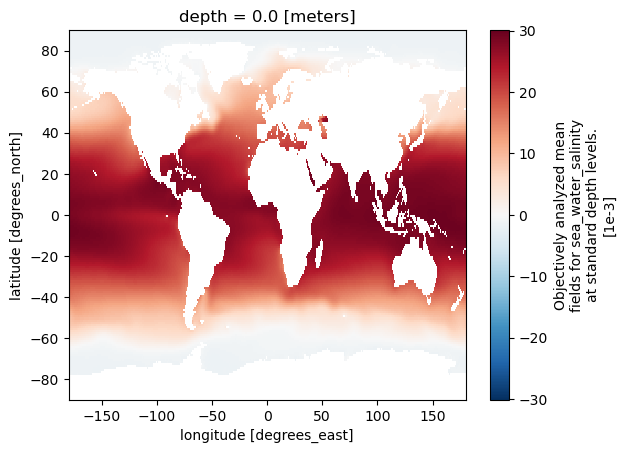

In [6]:
conservative_temp.sel(depth='0.00e+00').plot()

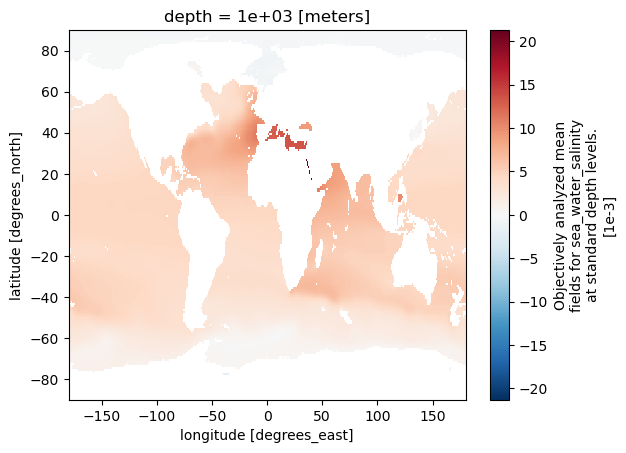

In [7]:
conservative_temp.sel(depth='1.00e+03').plot()

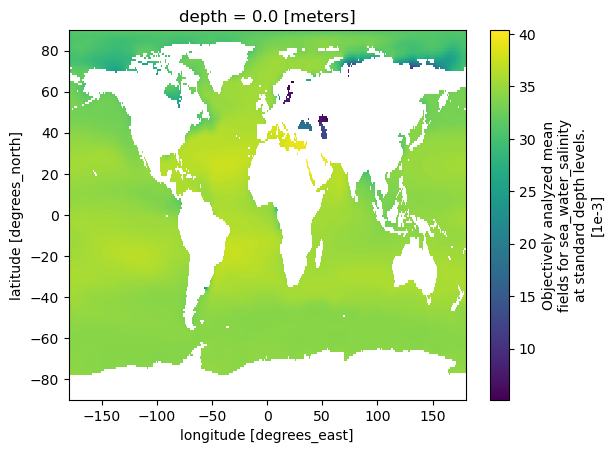

In [8]:
absolute_salt.sel(depth='0.00e+00').plot()

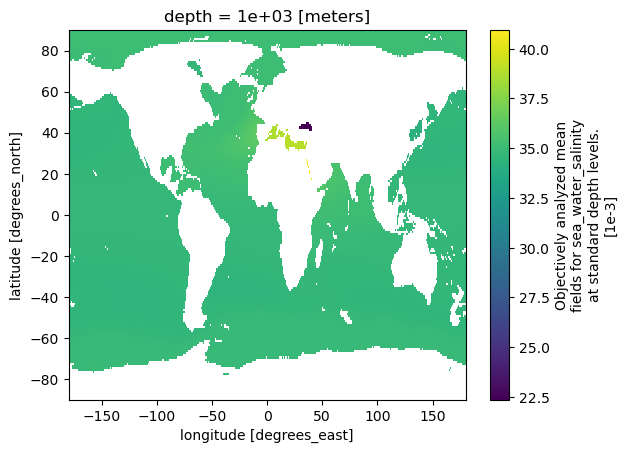

In [9]:
absolute_salt.sel(depth='1.00e+03').plot()

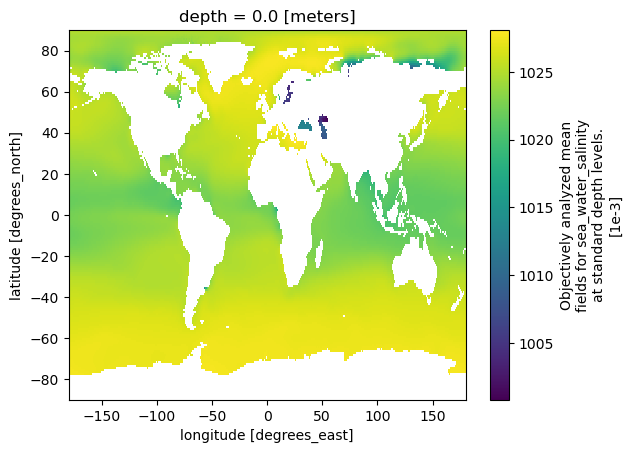

In [10]:
potential_density.sel(depth='0.00e+00').plot()

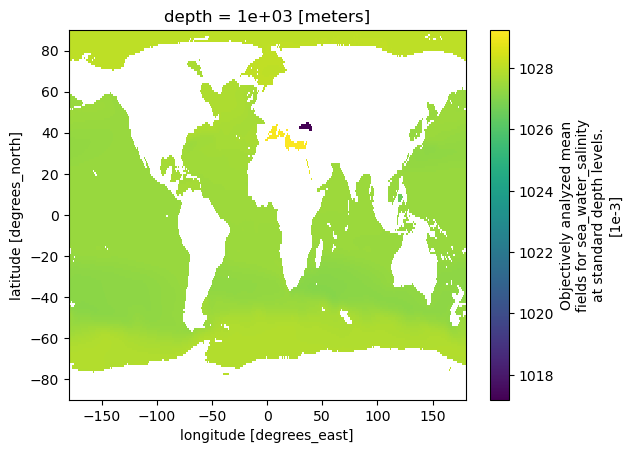

In [11]:
potential_density.sel(depth='1.00e+03').plot()

### todo: Write a few sentences about the patterns you observe (i.e. why is it warmer or saltier in certain regions?)

### todo: Plot a cross section of potential density at 30W longitude (across all latitudes)

Text(0.5, 0, 'Latitude')

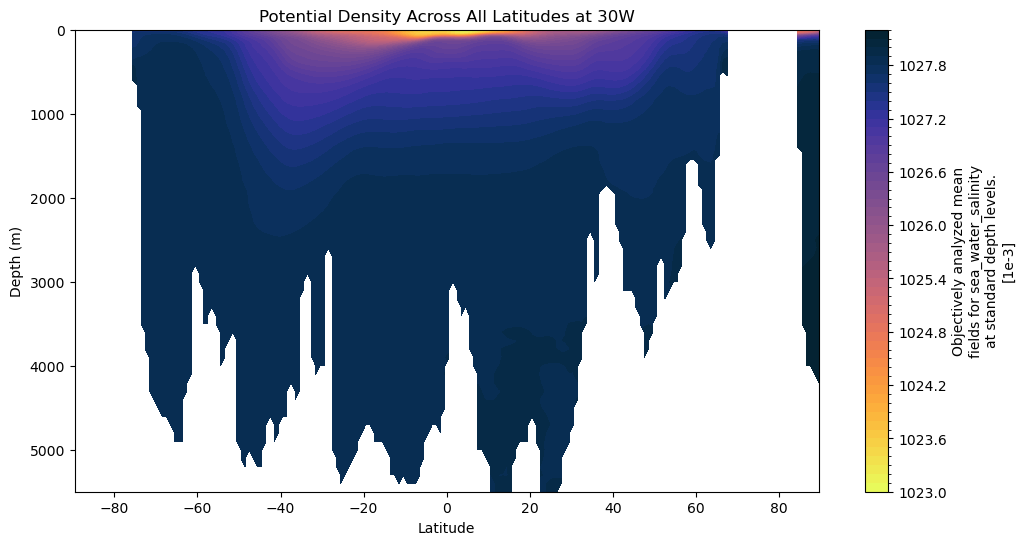

In [118]:
fig, ax = plt.subplots(figsize=(12, 6))

potential_density.sel(lon=-30.5).plot.contourf(yincrease=False, levels=60, cmap=cmocean.cm.thermal_r)

ax.set_title('Potential Density Across All Latitudes at 30W')

ax.set_ylabel('Depth (m)')

ax.set_xlabel('Latitude')

### todo: Along this cross-section, estimate and plot horizontal gradients of potential density ($\frac{\partial \sigma_0}{\partial y}$) 

(consider using the centered difference method and ignoring the latitudes for which a centered difference would be incomplete)

In [164]:
full_depth = potential_density.depth.values

In [165]:
dy = np.diff(potential_density.lat).mean() * 111e3  #Converts latitude degrees to meters, there are approximately 111km in a degree of latitude

In [166]:
dy

111000.0

In [167]:
rho_section = potential_density.sel(lon=-30.5)

In [134]:
rho_section

<xarray.DataArray 'salinity' (depth: 102, lat: 180)>
dask.array<getitem, shape=(102, 180), dtype=float64, chunksize=(26, 45), chunktype=numpy.ndarray>
Coordinates:
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat      (lat) float32 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
    lon      float32 -30.5
Attributes:
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    coordinates:    time lat lon depth
    grid_mapping:   crs
    long_name:      Objectively analyzed mean fields for sea_water_salinity a...
    standard_name:  sea_water_salinity
    units:          1e-3

In [159]:
rho = rho_section.transpose('lat', 'depth').values

In [155]:
d_rho_dy = np.zeros_like(rho)

In [156]:
d_rho_dy[1:-1, :] = (rho[2:, :] - rho[:-2, :]) / (2 * dy)

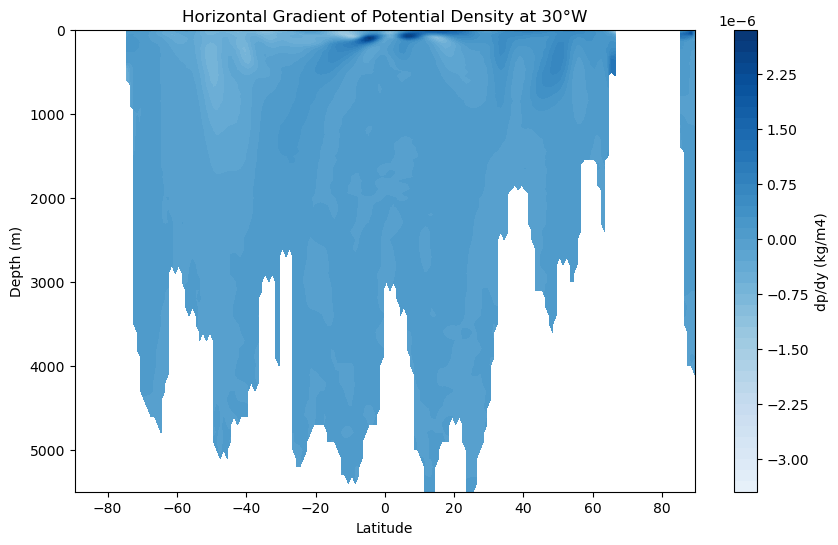

In [171]:
plt.figure(figsize=(10,6))

cf = plt.contourf(lat, full_depth, d_rho_dy.T, levels=50, vmin=-4e-6, vmax=3e-6, cmap='Blues')

plt.gca().invert_yaxis()

cbar = plt.colorbar(cf)
cbar.set_label('dp/dy (kg/m4)')

plt.xlabel('Latitude')
plt.ylabel('Depth (m)')
plt.title('Horizontal Gradient of Potential Density at 30°W')
plt.show()

### with horizontal gradients of potential density, we can estimate the vertical shear of zonal velocities as

$\Large\frac{\partial u}{\partial z} = \frac{g}{\rho_0 f} \frac{\partial \sigma_0}{\partial y}$

todo: evaluate the right hand side (compute and plot $\frac{\partial u}{\partial z}$)

In [115]:
g = 9.81
rho0 = 1025
Omega = 7.2921e-5

lat = potential_density.lat.values      
phi = np.deg2rad(lat)
f = 2 * Omega * np.sin(phi)

In [116]:
du_dz_calc = (g / (rho0 * f)) * d_rho_dy.T

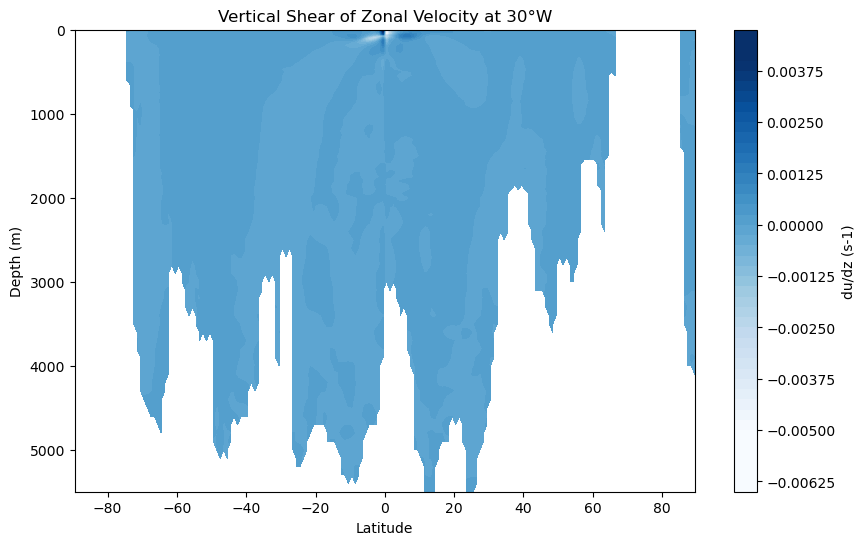

In [172]:
plt.figure(figsize=(10,6))

cf = plt.contourf(lat, full_depth, du_dz_calc, levels=50, vmin=-5e-3, vmax=4e-3, cmap='Blues')

plt.gca().invert_yaxis()

cbar = plt.colorbar(cf)
cbar.set_label('du/dz (s-1)')

plt.xlabel('Latitude')
plt.ylabel('Depth (m)')
plt.title('Vertical Shear of Zonal Velocity at 30°W')
plt.show()

### todo: select 1000 m as your reference level (or level of no motion) and cumulatively integrate from z = -1000 m to the surface to obtain a profile of zonal velocity $u$

We'll first ignore everything below z = -1000 m and assume $u$ is zero at z = -1000 m. At each latitude, calculate a cumulative vertical  sum of the right hand side, at each level multiplied by $dz$ (the vertical distance separating values), upwards from z = -1000 m ... this approximates a $du$ that when cumulatively summed approximated the total vertical integral.

todo: plot $u$ over this cross-section and across this depth range (spanning all latitudes between z = 0 m and z = -1000 m)

In [173]:
slice_at_30W = potential_density.sel(lon=-30.5)

In [174]:
thousandm = slice_at_30W.sel(depth=slice(0, 1000))

In [175]:
du_dz_da = xr.DataArray(thousandm, coords=[depth, lat], dims=['depth','lat'])

shear_0_1000 = du_dz_da.sel(depth=slice(0,1000))
depth_0_1000 = shear_0_1000.depth.values

In [176]:
shear_rev = shear_0_1000[::-1, :]
depth_rev = depth_0_1000[::-1]

dz = np.diff(depth_rev, prepend=depth_rev[0])

u_profile = np.cumsum(shear_rev * dz[:, np.newaxis], axis=0)

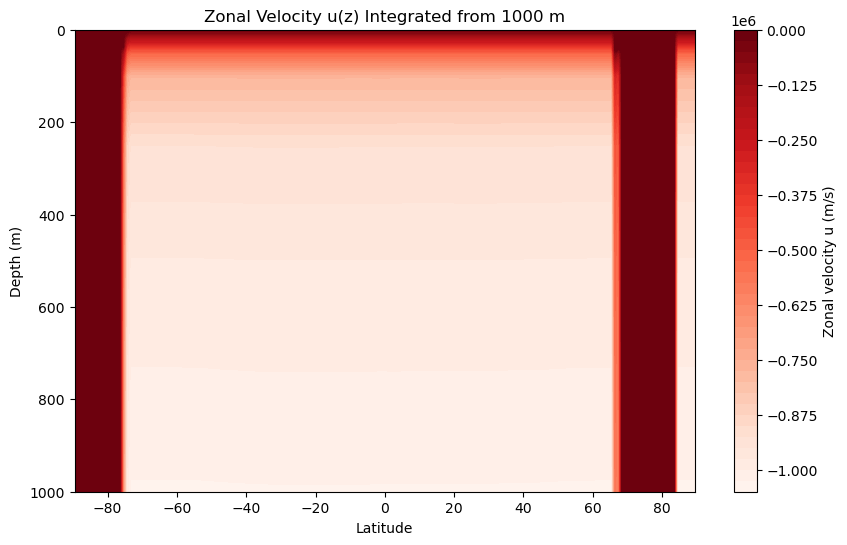

In [177]:
plt.figure(figsize=(10,6))
cf = plt.contourf(lat, depth, u_profile, levels=50, cmap='Reds')
plt.gca().invert_yaxis()
cbar = plt.colorbar(cf)
cbar.set_label('Zonal velocity u (m/s)')
plt.xlabel('Latitude')
plt.ylabel('Depth (m)')
plt.title('Zonal Velocity u(z) Integrated from 1000 m')
plt.show()

### todo: redo the above calculation starting at z = -3000 m and then again at the seafloor

In [180]:
threethousandm = slice_at_30W.sel(depth=slice(0, 3000))

In [181]:
du_dz_da3 = xr.DataArray(threethousandm, coords=[depth, lat], dims=['depth','lat'])

shear_0_3000 = du_dz_da3.sel(depth=slice(0,3000))
depth_0_3000 = shear_0_3000.depth.values

ValueError: conflicting sizes for dimension 'depth': length 77 on the data but length 47 on coordinate 'depth'

### todo: consider how estimates of $u$ over the upper 1000 m change as the refence level deepends. Write a few sentences about these differences, describe the features of $u$ that you observe, and connect them to know currents. 